In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [7]:
df = pd.read_csv("student_clustering.csv")

In [8]:
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [10]:
df.shape

(200, 2)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    200 non-null    float64
 1   iq      200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


In [14]:
df.describe()

,cgpa,iq
count,200.000000,200.000000
mean,6.983400,101.995000
std,1.624101,12.161599
min,4.600000,83.000000
25%,5.407500,91.000000
50%,7.040000,102.000000
75%,8.585000,113.000000
max,9.300000,121.000000


In [15]:
df.isnull().sum()

cgpa    0
iq      0
dtype: int64

In [16]:
X = df[['cgpa', 'iq']]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled[:5]

array([[-1.14404869, -1.15364097],
       [-0.6687506 ,  0.9071682 ],
       [ 0.84973424, -0.74147914],
       [ 0.79417991, -0.41174967],
       [-0.94652221,  0.6598711 ]])

In [19]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

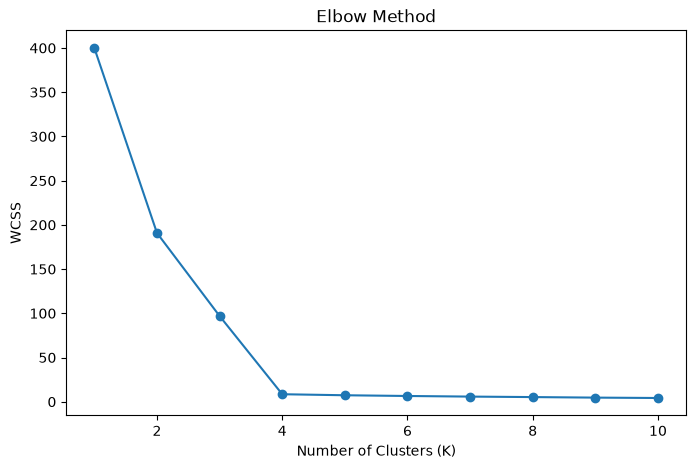

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [21]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

In [22]:
df['Cluster'] = labels

df.head()

,cgpa,iq,Cluster
0,5.13,88,1
1,5.90,113,2
2,8.36,93,2
3,8.27,97,2
4,5.45,110,2


In [23]:
df['Cluster'].value_counts()

Cluster
2    100
1     50
0     50
Name: count, dtype: int64

In [24]:
kmeans.cluster_centers_

array([[ 1.16540625,  1.25008684],
       [-1.24429338, -1.26080305],
       [ 0.03944357,  0.0053581 ]])

In [25]:
silhouette_score(X_scaled, labels)

0.6491417673187647

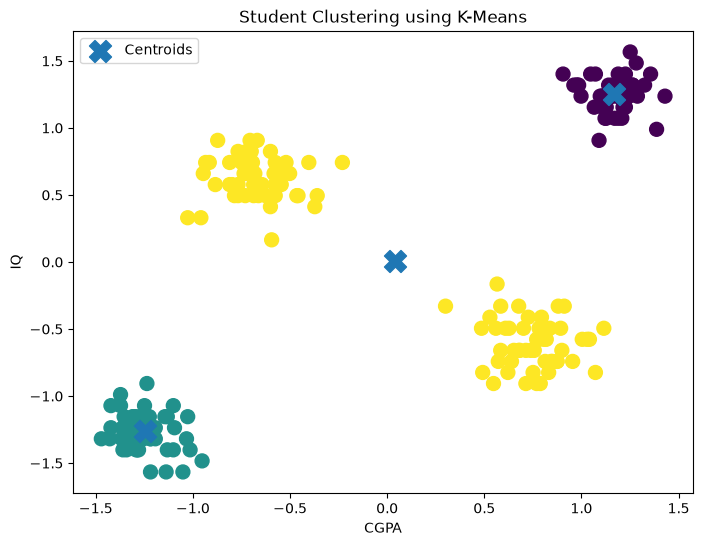

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Student Clustering using K-Means")
plt.legend()

plt.show()

In [27]:
df.head(10)

,cgpa,iq,Cluster
0,5.13,88,1
1,5.90,113,2
2,8.36,93,2
3,8.27,97,2
4,5.45,110,2
5,5.88,109,2
6,8.41,98,2
7,8.80,115,0
8,5.79,110,2
9,8.09,94,2


In [28]:
df.to_csv("student_clustering_result.csv", index=False)